## CNN classifier for landcover classification from remote sensing images

In this tasks, we will again use the same portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

In this notebook, we will make use of small CNN network on the same subset of SAT-6 dataset that we used in the last exercise

In [1]:
# CNN classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updqated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib
#!pip install torch

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [3]:
# uncomment the following lines if you haven't downloaded the data already
# !mkdir -p data
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv

In [4]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


# Read annotation labels from different csv file

In [5]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
labels_1 = labels
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


**Reminder :**  The data structure that you see above is called _one-hot encoding_


In [6]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Plot few samples to see visually the data and gain more insights on how to reshape the 1d data to a 4 channel image (RGB & NIR)

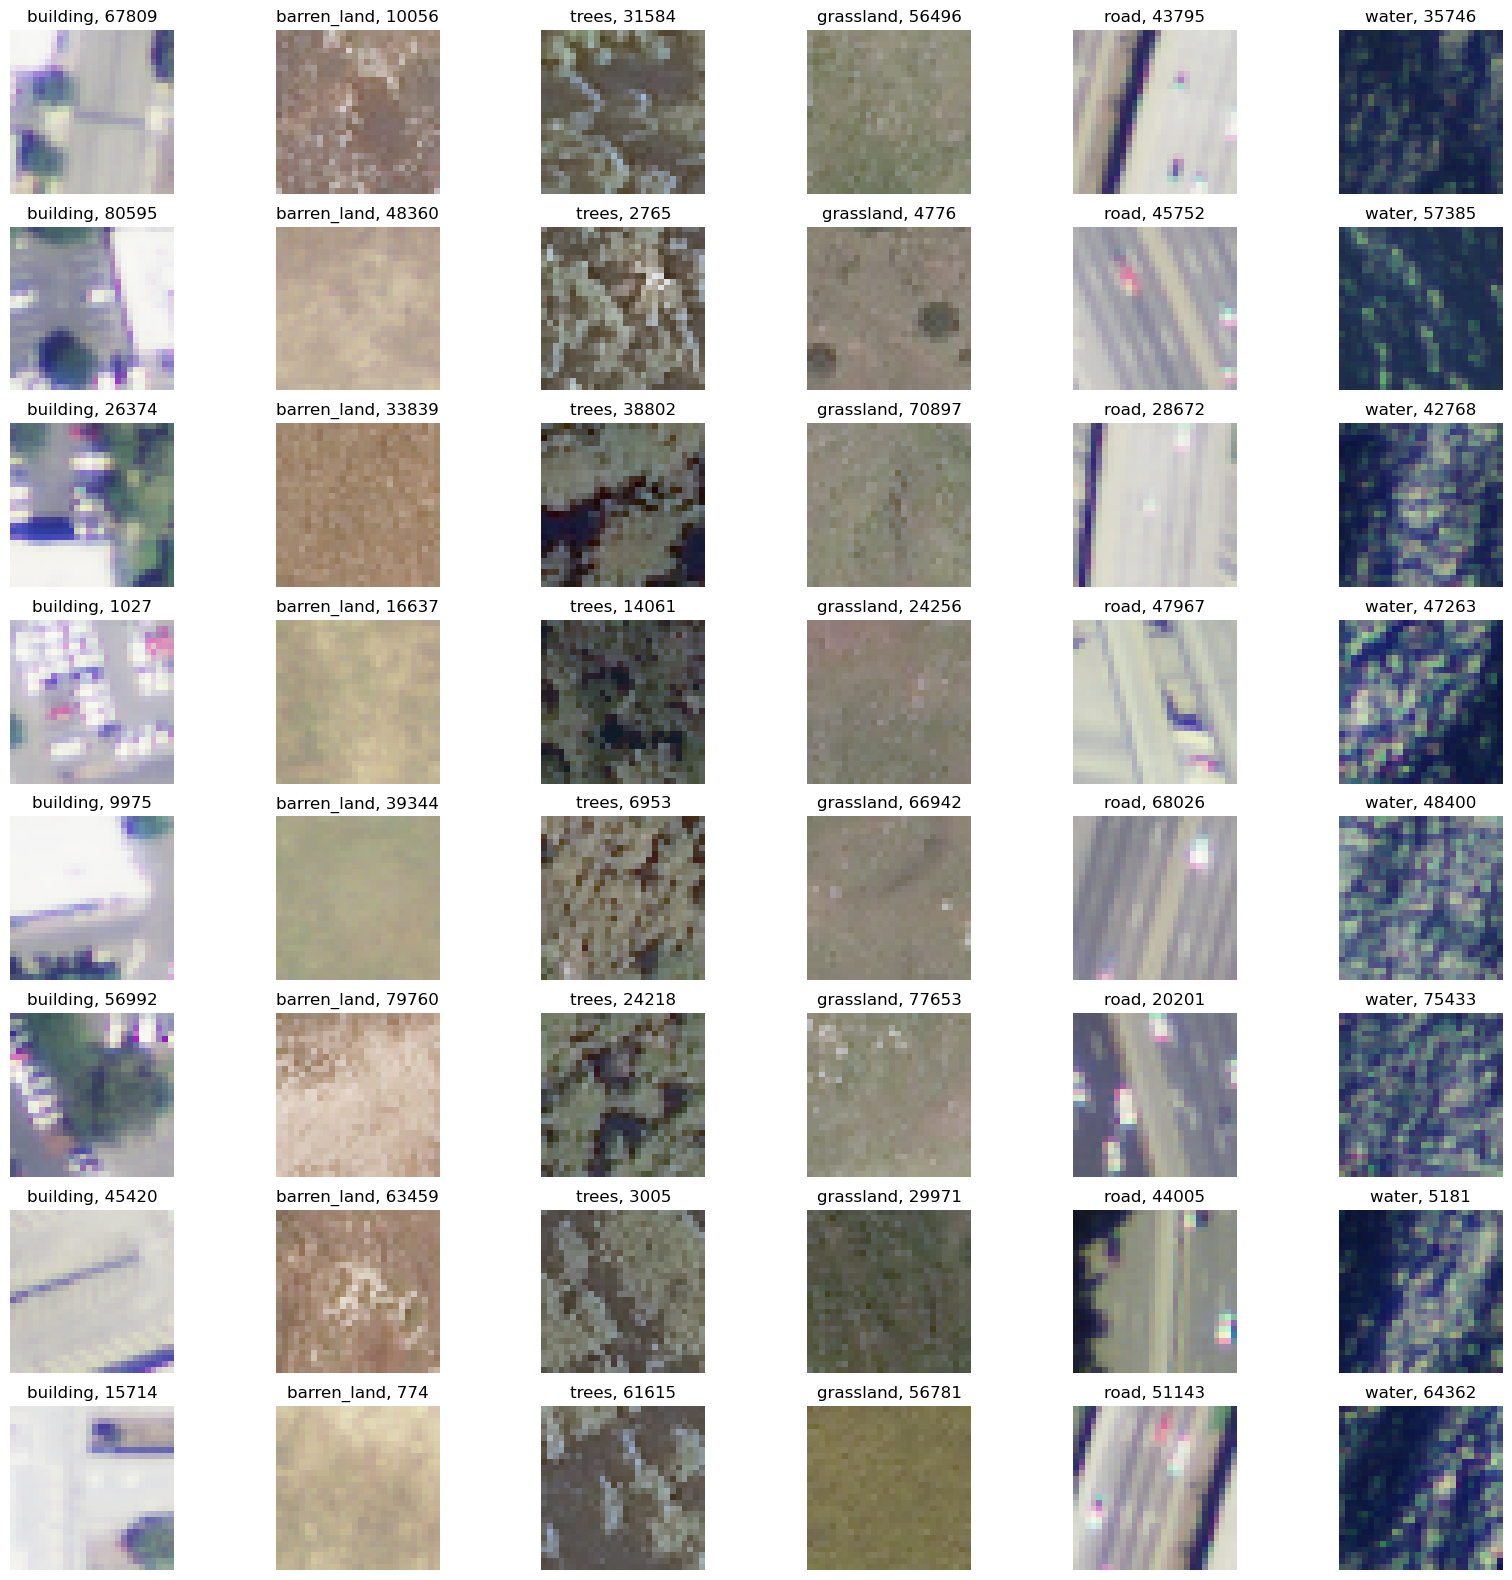

In [7]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

The dataset is not balanced. Use ***num_train*** and ***num_test*** as a definite integer number.

Note: the maximum we tried is ***num_train*** = 2000 and ***num_test*** = 200. Beyond that for some classes, we did not find that many samples

In case you want all samples for training then use ***num_train*** = -1

In [8]:
num_train = 1000 #replace with -1 if all samples need to be used for training
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    valid_indices = np.where(class_idx.values)[0]
    random_indices = np.random.permutation(valid_indices)
    test_idx.extend(random_indices[:num_test])
    train_idx.extend(random_indices[num_test:num_test+num_train if num_train != -1 else num_train])
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


In [9]:
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

# Calculate Normalization Parameter using Train Dataset

In [10]:
train_X_reshape = train_X.values.reshape((-1,28,28,4))
mean_per_channels = np.mean(train_X_reshape,axis=(0,1,2)).astype(np.float32)
std_per_channels = np.std(train_X_reshape,axis=(0,1,2)).astype(np.float32)
mean_per_channels, std_per_channels

(array([132.2212 , 132.30948, 129.5741 , 120.26106], dtype=float32),
 array([55.494076, 51.125565, 47.033436, 65.692825], dtype=float32))

## Define torch dataset

From here, we will make use of general workflow of PyTorch. First thing is to create a dataset. We are making use of mapped-style dataset. [Refer this page for more details](https://pytorch.org/docs/stable/data.html#map-style-datasets)

Important thing is to define the total length under function *__len__* and data corresponding to the index under *__getitem__*

In [11]:
class SAT6Dataset(Dataset):
  def __init__(self,data_df,label_df, normalization_parameter):
    super(SAT6Dataset,self).__init__()
    self.data_df = data_df
    self.label_df = label_df
    self.normalization = normalization_parameter

  def __len__(self):
    return len(self.data_df)

  def __getitem__(self,idx):
    data = self.data_df.iloc[idx].values.reshape((28,28,4)).astype(np.float32)
    data = (data-self.normalization[0])/self.normalization[1]
    #data = data/255.0
    data = np.transpose(data,axes=(2,0,1))  # swap dimensions: channel first
    label = self.label_df.iloc[idx].values
    label_args = np.where(label==1)[0]

    return (data,label_args[0])

In [12]:
# define two dataset one for train and other for test
sat6_train_dataset = SAT6Dataset(train_X,train_y,(mean_per_channels,std_per_channels))
sat6_test_dataset = SAT6Dataset(test_X,test_y,(mean_per_channels,std_per_channels))

Now, we will use **torch.nn.Module** to build our CNN model.

**Important points:**

*   To build modules in a list use **torch.nn.ModuleList()** instead of native list.

*   Define **forward** function to define the step-by-step mathematical transformation




In [13]:
class CNN(torch.nn.Module):
  def __init__(self,
               input_shape,
               num_conv_layers,
               channels_each_layer,
               kernel_size,
               mlp_dimension,
               activation_func,
               pooling,
               input_channels,
               num_classes,
               norm="batch_norm"):
    super(CNN,self).__init__()
    self.num_conv_layers = num_conv_layers
    self.channels_each_layer = channels_each_layer
    assert num_conv_layers == len(channels_each_layer),"Number of conv layers does not match with given number of channels"
    self.kernel_size = ([kernel_size] * num_conv_layers
                        if type(kernel_size) == int
                        else kernel_size)
    self.mlp_dimension = mlp_dimension
    if activation_func == 'relu':
      self.activation_func = torch.nn.ReLU()
    elif activation_func == 'tanh':
      self.activation_func = torch.nn.Tanh()
    else:
      assert False, "Currently only relu and tanh are provided in this code"

    if pooling == "max":
      self.pooling = torch.nn.AvgPool2d(kernel_size=2, stride=2)
    else:
      self.pooling = torch.nn.MaxPool2d(kernel_size=2, stride=2)

    self.input_channels = input_channels
    if norm=="batch_norm":
      self.batch_norms = [torch.nn.BatchNorm2d(channels_each_layer[i])
                          for i in range(len(self.kernel_size))]
    elif norm == "identity":
      self.batch_norms = [torch.nn.Identity() for i in range(len(self.kernel_size))]
    else:
      assert False,"only batch norm is provided in this code"

    self.conv_modules = torch.nn.ModuleList()

    for i in range(num_conv_layers):
      self.conv_modules.append(
          torch.nn.Conv2d(input_channels if i==0 else channels_each_layer[i-1],
                          channels_each_layer[i],
                          self.kernel_size[i],
                          stride=1,
                          padding='same',
                          bias=True))
      self.conv_modules.append(self.batch_norms[i])
      self.conv_modules.append(self.activation_func)
      self.conv_modules.append(self.pooling)
    dim_after_final_conv_layer = (input_shape[0]//2**num_conv_layers)*(
        input_shape[1]//2**num_conv_layers)*(
            channels_each_layer[-1])
    self.mlp_layer_modules = torch.nn.ModuleList()
    self.mlp_dimension = ([mlp_dimension]
                          if type(mlp_dimension) == int
                          else mlp_dimension)

    for i in range(len(self.mlp_dimension)):
      self.mlp_layer_modules.append(
          torch.nn.Linear((dim_after_final_conv_layer
                           if i==0
                           else self.mlp_dimension[i-1]),
                          self.mlp_dimension[i]))
      # Incase one want to try batch norm uncomment below line
      #self.mlp_layer_modules.append(torch.nn.BatchNorm1d(mlp_dimension[i]))
      self.mlp_layer_modules.append(self.activation_func)
    self.mlp_layer_modules.append(
        torch.nn.Linear(self.mlp_dimension[-1],num_classes))

  def forward(self,x):
    for module in self.conv_modules:
      x = module(x)
    x = x.flatten(1)
    for module in self.mlp_layer_modules:
      x = module(x)
    return x

Define the device (**GPU** if you use GPU as your runtime) else it will run on **CPU**)
Instatiation of the CNN model is also define in this cell

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn = CNN((28,28),3,[32,64,128],[5,3,3],[32],"relu","max",4,6,norm="identity").to(device)


cuda:0


In [15]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.version.cuda)

True
1
12.8


In [16]:
# Overview of the model
print(cnn)

CNN(
  (activation_func): ReLU()
  (pooling): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv_modules): ModuleList(
    (0): Conv2d(4, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (1): Identity()
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): Identity()
    (6): ReLU()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): Identity()
    (10): ReLU()
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (mlp_layer_modules): ModuleList(
    (0): Linear(in_features=1152, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=6, bias=True)
  )
)


Define training parameters


*   Optimizer : This reulates the rate of learning. USe wither adam or SGD. For other optimizers, feel free to add them.
*   Scheduler : It updates the learning rate during the training process. We have commented here out. PLease feel free to play with it.
*   Loss function: As it is a multi-class classification problem, CrossEntropy is a suitable loss function.



In [17]:
optim = "adam"
optimizer = torch.optim.Adam(cnn.parameters(),lr=0.001) if optim == "adam" else torch.optim.SGD(cnn.parameters(),lr=0.1)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=10,gamma=0.1)
loss_fn = torch.nn.CrossEntropyLoss()

Previously, we have defined dataset which takes an index as a parameter and provides data corresponding to the index. In such deep learning problems, we process them in a batch. The DataLoader takes control of such requirements by defining the parameters **batch_size** and **shuffle**.

**Note:**


*   In training, we want each time to have different samples in a batch. The ***shuffle*=True** ensures that. For validation, we do not required such shuffling, hence it is set to False
*   We used the whole length of test dataset as it is small. Incase of any issue with large number of test samples, feel free to decrease the number such as $256$



In [18]:
train_dataloader = DataLoader(sat6_train_dataset,batch_size=256,shuffle=True,drop_last=True)
test_dataloader = DataLoader(sat6_test_dataset,len(sat6_test_dataset), shuffle=False)

# Training Routine
Define number of epochs for the training.


In [19]:
num_epochs = 10
training_loss_per_epoch = []
validation_loss_per_epoch = []
acc_per_epoch = []

with tqdm(total=num_epochs) as pbar:
  for i in range(num_epochs):
    cnn.train()
    for train_data_idx, train_data in enumerate(train_dataloader):
      optimizer.zero_grad()
      data, labels = train_data
      data = data.to(device)
      labels = labels.to(device)
      preds = cnn(data)
      train_loss = loss_fn(preds,labels)
      train_loss.backward()
      optimizer.step()
    # uncomment incase scheduler is defined above
    #scheduler.step()
    training_loss_per_epoch.append(train_loss.item())

    cnn.eval()
    pred_labels = []
    true_labels = []
    with torch.no_grad():
      for test_data_idx, test_data in enumerate(test_dataloader):
        data, labels = test_data
        data = data.to(device)
        labels = labels.to(device)
        preds = cnn(data)
        val_loss = loss_fn(preds,labels)
        pred_labels.extend(torch.argmax(preds,dim=1).to('cpu'))
        true_labels.extend(torch.squeeze(labels).to('cpu'))
    validation_loss_per_epoch.append(val_loss.item())
    acc = accuracy_score(true_labels,pred_labels)
    acc_per_epoch.append(acc)
    pbar.set_description(f"Epoch {i+1}/{num_epochs}: training_loss : {train_loss}, validation_loss : {val_loss} and accuracy : {acc} ")



Epoch 10/10: training_loss : 0.15804022550582886, validation_loss : 0.1272173523902893 and accuracy : 0.94 :   0%|          | 0/10 [00:08<?, ?it/s]             


The variables **training_loss_per_epoch**, **validation_loss_per_epoch**, and **acc_per_epoch** contains metrics after each epoch. Try to plot them to see how was the progress during training.

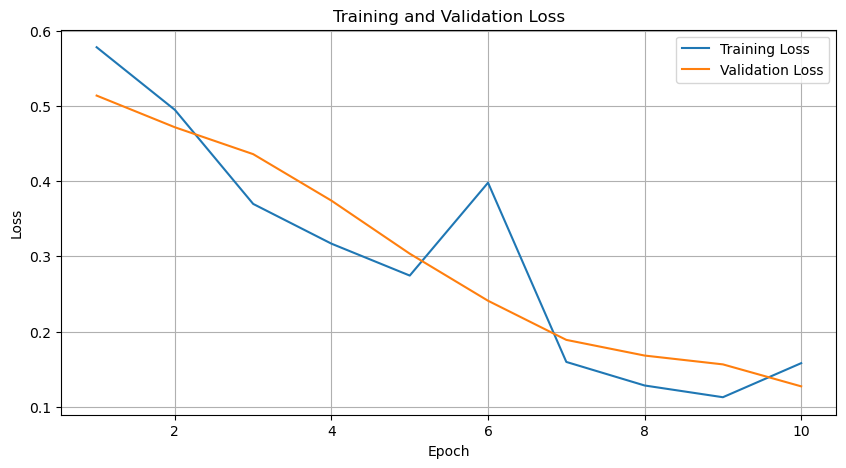

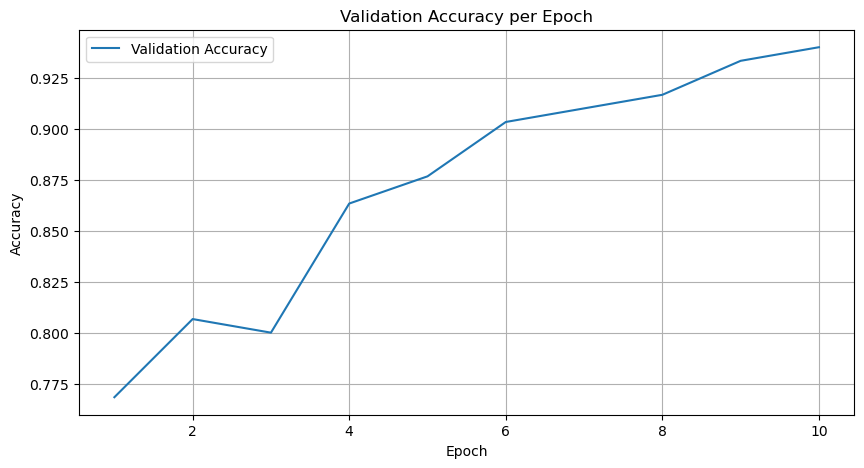

In [20]:
# Create epoch index
epochs = range(1, len(training_loss_per_epoch) + 1)

# Plot training and validation loss
plt.figure(figsize=(10,5))
plt.plot(epochs, training_loss_per_epoch, label="Training Loss")
plt.plot(epochs, validation_loss_per_epoch, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, acc_per_epoch, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)

plt.show()

# Task 3.2

Add some code to the notebook to evaluate the classification accuracy of each class and to plot a small number of correct classification examples and a small number of misclassifications.

building: 0.9500
barren_land: 0.9400
trees: 0.9900
grassland: 0.8900
road: 0.8700
water: 1.0000


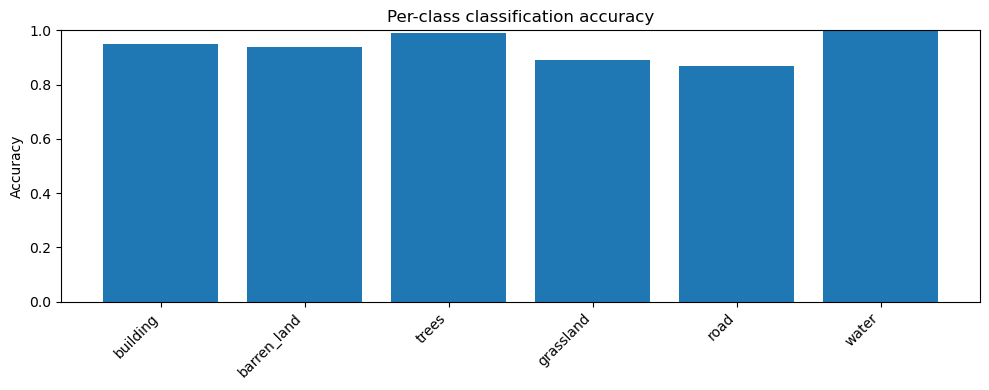

In [21]:
y_pred = np.array(pred_labels)
true_class = np.array(true_labels)

acc_per_class = {}

for i, column in enumerate(labels_1):
    idx = true_class == i
    acc = accuracy_score(true_class[idx], y_pred[idx])
    acc_per_class[column] = acc
    print(f"{column}: {acc:.4f}")

# plot per-class accuracy
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(acc_per_class.keys(), acc_per_class.values())
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Per-class classification accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'test_X_tensor' is not defined

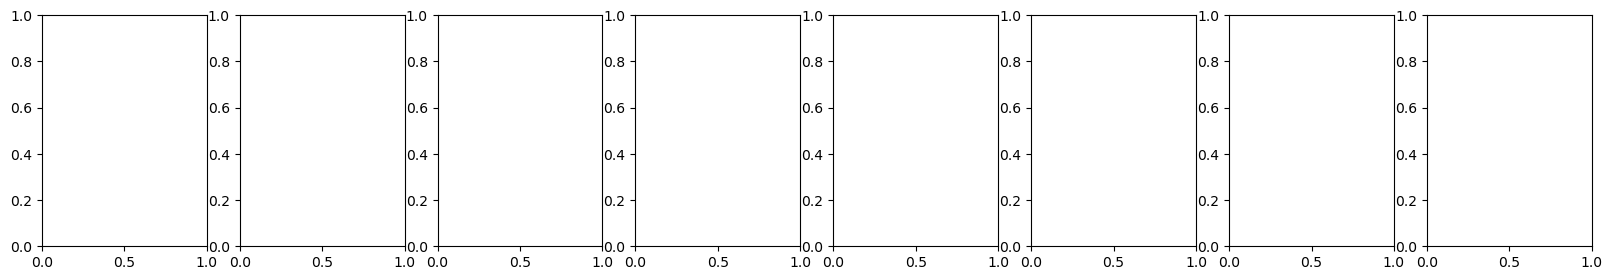

In [22]:
true_class = np.array(true_labels)
pred_class = np.array(pred_labels)

correct_mask = pred_class == true_class
incorrect_mask = ~correct_mask

correct_positions = np.where(correct_mask)[0]
incorrect_positions = np.where(incorrect_mask)[0]

num_examples = 8 # number of examples to display per row

# Randomly pick examples
rng = np.random.default_rng()

# randomly pick a number of unique samples where predicited and true class match as well as differs
# size=min(num_examples, ...) ensures that even if fewer than num_examples unique samples exists the code is not crashing
# replace = False means without repetition

correct_pick = rng.choice(
    correct_positions,
    size=min(num_examples, len(correct_positions)),
    replace=False
)

incorrect_pick = rng.choice(
    incorrect_positions,
    size=min(num_examples, len(incorrect_positions)),
    replace=False
)

def plot_examples(positions, title):
    n = len(positions)
    fig, ax = plt.subplots(1, n, figsize=(2.5 * n, 3))

    if n == 1:
        ax = [ax]

    for k, pos in enumerate(positions):

        img = test_X_tensor[pos].cpu().numpy()
        #print("Here: ", img)

        # denormalize to properly display the images 
        mean = np.array(sat6_test_dataset.normalization[0], dtype=np.float32).reshape(4,1,1)
        std = np.array(sat6_test_dataset.normalization[1], dtype=np.float32).reshape(4,1,1)
        
        img = img * std + mean
        #print("Denormalize: ", img)
        img = np.clip(img, 0, 255)
        #print("Clip: ", img)
        img = np.transpose(img, (1, 2, 0))
        #print("Transpose: ", img)
        img_rgb = img[:, :, :3] / 255.0
        #print("Scale: ", img_rgb)

        ax[k].imshow(img_rgb)
        ax[k].axis('off')

        true_name = str(labels[true_class[pos]])
        pred_name = str(labels[pred_class[pos]])

        ax[k].set_title(f"T: {true_name}\nP: {pred_name}", fontsize=9)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

plot_examples(correct_pick, "Correct classifications")
plot_examples(incorrect_pick, "Misclassifications")

# Task 3.3

Modify the CNN classifier so that it only uses the R, G, and B channels.

In [ ]:
# class that creates a variant of the dataset that only contains RGB channels
class SAT6Dataset(Dataset):
  def __init__(self,data_df,label_df, normalization_parameter):
    super(SAT6Dataset,self).__init__()
    self.data_df = data_df
    self.label_df = label_df
    self.normalization = normalization_parameter

  def __len__(self):
    return len(self.data_df)

  def __getitem__(self,idx):
    data = self.data_df.iloc[idx].values.reshape((28,28,4)).astype(np.float32)

    # only select RGB channels
    data = data[:, :, :3]

    mean = self.normalization[0][:3]
    std = self.normalization[1][:3]

    data = (data - mean) / std

    data = np.transpose(data,axes=(2,0,1))

    label = self.label_df.iloc[idx].values
    label_args = np.where(label==1)[0]

    return (data,label_args[0])

sat6_train_dataset_rgb = SAT6Dataset(train_X, train_y, (mean_per_channels, std_per_channels))
sat6_test_dataset_rgb  = SAT6Dataset(test_X,  test_y,  (mean_per_channels, std_per_channels))

train_dataloader_rgb = DataLoader(sat6_train_dataset_rgb, batch_size=256, shuffle=True, drop_last=True)
test_dataloader_rgb  = DataLoader(sat6_test_dataset_rgb,  len(sat6_test_dataset_rgb), shuffle=False)

In [ ]:
# create a new CNN specificially for taking only the 3 RGB channels
cnn_rgb = CNN((28,28),3,[32,64,128],[5,3,3],[32],"relu","max",3,6,norm="identity").to(device)
optimizer = torch.optim.Adam(cnn_rgb.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
num_epochs = 10
training_loss_per_epoch_rgb = []
validation_loss_per_epoch_rgb = []
acc_per_epoch_rgb = []

with tqdm(total=num_epochs) as pbar:
  for i in range(num_epochs):
    cnn_rgb.train()
    for train_data_idx, train_data in enumerate(train_dataloader_rgb):
      optimizer.zero_grad()
      data, labels = train_data
      data = data.to(device)
      labels = labels.to(device)
      preds = cnn_rgb(data)
      train_loss = loss_fn(preds,labels)
      train_loss.backward()
      optimizer.step()
    # uncomment incase scheduler is defined above
    #scheduler.step()
    training_loss_per_epoch_rgb.append(train_loss.item())

    cnn_rgb.eval()
    pred_labels = []
    true_labels = []
    with torch.no_grad():
      for test_data_idx, test_data in enumerate(test_dataloader_rgb):
        data, labels = test_data
        data = data.to(device)
        labels = labels.to(device)
        preds = cnn_rgb(data)
        val_loss = loss_fn(preds,labels)
        pred_labels.extend(torch.argmax(preds,dim=1).to('cpu'))
        true_labels.extend(torch.squeeze(labels).to('cpu'))
    validation_loss_per_epoch_rgb.append(val_loss.item())
    acc = accuracy_score(true_labels,pred_labels)
    acc_per_epoch_rgb.append(acc)
    pbar.set_description(f"Epoch {i+1}/{num_epochs}: training_loss : {train_loss}, validation_loss : {val_loss} and accuracy : {acc} ")

In [ ]:
# Create epoch index
epochs = range(1, len(training_loss_per_epoch_rgb) + 1)

# Plot training and validation loss
plt.figure(figsize=(10,5))
plt.plot(epochs, training_loss_per_epoch_rgb, label="Training Loss")
plt.plot(epochs, validation_loss_per_epoch_rgb, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, acc_per_epoch_rgb, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
y_pred = np.array(pred_labels)
true_class = np.array(true_labels)

acc_per_class = {}

for i, column in enumerate(labels_1):
    idx = true_class == i
    acc = accuracy_score(true_class[idx], y_pred[idx])
    acc_per_class[column] = acc
    print(f"{column}: {acc:.4f}")

# plot per-class accuracy
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(acc_per_class.keys(), acc_per_class.values())
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Per-class classification accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task 3.4

Choose one hyper parameter of the CNN architecture or the training and modify its value.

In [ ]:
cnn_epoch = CNN((28,28),3,[32,64,128],[5,3,3],[32],"relu","max",4,6,norm="identity").to(device)
optimizer = torch.optim.Adam(cnn_epoch.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
num_epochs = 50

training_loss_per_epoch = []
validation_loss_per_epoch = []
acc_per_epoch = []

with tqdm(total=num_epochs) as pbar:
    for i in range(num_epochs):
        cnn_epoch.train()
        for train_data_idx, train_data in enumerate(train_dataloader):
            optimizer.zero_grad()
            data, labels = train_data
            data = data.to(device)
            labels = labels.to(device)
            preds = cnn_epoch(data)
            train_loss = loss_fn(preds, labels)
            train_loss.backward()
            optimizer.step()
        training_loss_per_epoch.append(train_loss.item())

        cnn_epoch.eval()
        pred_labels = []
        true_labels = []
        with torch.no_grad():
            for test_data in test_dataloader:
                data, labels = test_data
                data = data.to(device)
                labels = labels.to(device)
                preds = cnn_epoch(data)
                val_loss = loss_fn(preds, labels)
                pred_labels.extend(torch.argmax(preds, dim=1).to('cpu'))
                true_labels.extend(torch.squeeze(labels).to('cpu'))
        validation_loss_per_epoch.append(val_loss.item())
        acc = accuracy_score(true_labels, pred_labels)
        acc_per_epoch.append(acc)
        pbar.update(1)
        pbar.set_description(
            f"Epoch {i+1}/{num_epochs}: train_loss={train_loss.item():.4f}, "
            f"val_loss={val_loss.item():.4f}, acc={acc:.4f}"
        )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, num_epochs + 1), training_loss_per_epoch, label="Training loss")
axes[0].plot(range(1, num_epochs + 1), validation_loss_per_epoch, label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss curves")
axes[0].legend()

axes[1].plot(range(1, num_epochs + 1), acc_per_epoch, color="tab:green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Accuracy curve")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(acc_per_epoch)) + 1
worst_epoch = int(np.argmin(acc_per_epoch)) + 1
print(f"Best validation accuracy: {max(acc_per_epoch):.4f} in epoche {best_epoch}")
print(f"Worst validation accuracy: {min(acc_per_epoch):.4f} in epoche {worst_epoch}")
print(f"Validation accuracy in last epoche: {acc_per_epoch[-1]:.4f}")

In [ ]:
y_pred = np.array(pred_labels)
true_class = np.array(true_labels)

acc_per_class = {}

for i, column in enumerate(labels_1):
    idx = true_class == i
    acc = accuracy_score(true_class[idx], y_pred[idx])
    acc_per_class[column] = acc
    print(f"{column}: {acc:.4f}")

# plot per-class accuracy
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(acc_per_class.keys(), acc_per_class.values())
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Per-class classification accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()